In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re
import nltk

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SANKET\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SANKET\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SANKET\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\SANKET\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']] 
df.columns = ['Label', 'Text']

In [4]:
def clean_text(text):
    text = text.lower() # Convert to lowercase [cite: 977]
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers 
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)

In [5]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=20) 
tfidf_matrix = vectorizer.fit_transform(df['Clean_Text'])
feature_names = vectorizer.get_feature_names_out()

In [6]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

In [7]:
importance = tfidf_df.mean().sort_values(ascending=False)

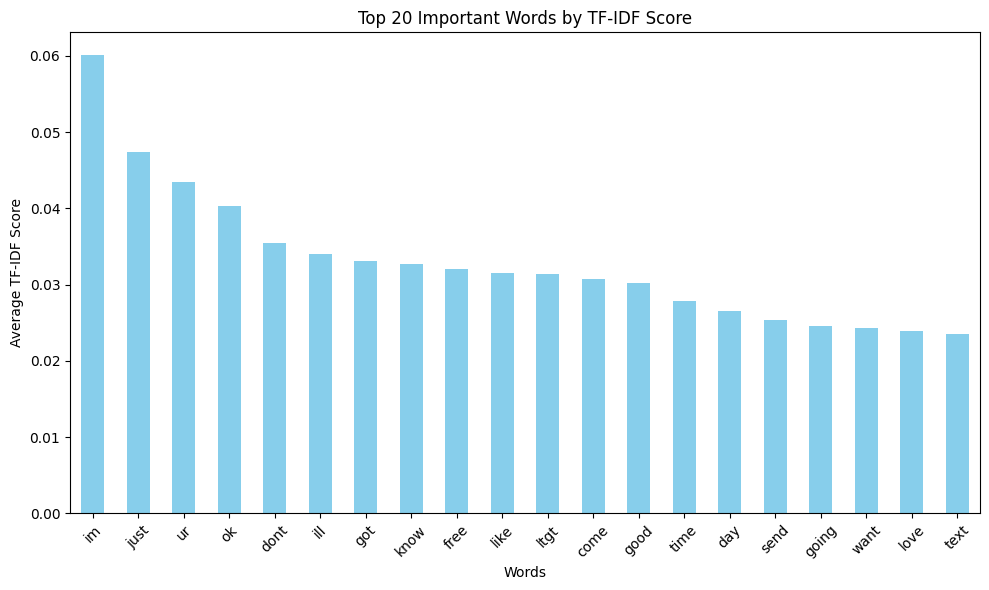

In [8]:
plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='skyblue')
plt.title('Top 20 Important Words by TF-IDF Score')
plt.xlabel('Words')
plt.ylabel('Average TF-IDF Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
print("Sample TF-IDF Matrix (First 5 rows):")
print(tfidf_df.head())

Sample TF-IDF Matrix (First 5 rows):
   come  day  dont      free  going  good  got  ill   im  just  know  like  \
0   0.0  0.0   0.0  0.000000    0.0   0.0  1.0  0.0  0.0   0.0   0.0   0.0   
1   0.0  0.0   0.0  0.000000    0.0   0.0  0.0  0.0  0.0   0.0   0.0   0.0   
2   0.0  0.0   0.0  0.683771    0.0   0.0  0.0  0.0  0.0   0.0   0.0   0.0   
3   0.0  0.0   0.0  0.000000    0.0   0.0  0.0  0.0  0.0   0.0   0.0   0.0   
4   0.0  0.0   1.0  0.000000    0.0   0.0  0.0  0.0  0.0   0.0   0.0   0.0   

   love  ltgt   ok  send      text  time   ur  want  
0   0.0   0.0  0.0   0.0  0.000000   0.0  0.0   0.0  
1   0.0   0.0  1.0   0.0  0.000000   0.0  0.0   0.0  
2   0.0   0.0  0.0   0.0  0.729697   0.0  0.0   0.0  
3   0.0   0.0  0.0   0.0  0.000000   0.0  0.0   0.0  
4   0.0   0.0  0.0   0.0  0.000000   0.0  0.0   0.0  
